# Working with APIs in Python
### ISA 383: Python for Business | American University of Sharjah

**Learning Objectives:**
- Understand what a web API is and how it differs from web scraping
- Use the `requests` library to make a first call by hand and read JSON responses
- Know where API keys go, what rate limits are, and how to handle errors cleanly
- **Use popular Python wrapper packages** to pull data from Yahoo Finance, the World Bank, OpenStreetMap, Wikipedia, and FRED with minimal code
- Combine multiple packages into a small end-to-end analysis

**Philosophy of this lab:** the `requests` library is the *universal* way to talk to any API on the planet -- we cover it first so you understand the mechanics. For popular APIs, however, somebody has usually already wrapped them in a neat Python package. Most of this lab is about **using those packages well**, because that is how real-world business Python code is written.

---


## Using this notebook in Google Colab

1. Before editing, select **File > Save a copy in Drive**.
2. Run the cells in order. Some practice cells intentionally wait for your input.
3. The notebook creates any course folders and teaching files it needs automatically.
4. Files under `/content` are temporary and disappear when the Colab runtime resets.
5. Never paste an API key into a notebook cell. Use the **Secrets** panel when instructed.

You do not need to find, copy, or type a file path for the prepared course data.


## 1. What is an API?

An **API** (Application Programming Interface) is a contract between two programs. On the web, that contract usually works like this:

1. You send an HTTP request to a URL.
2. The server replies with a **status code** and a structured body -- almost always **JSON**.
3. You parse the JSON into Python dictionaries and lists.

Compare this to web scraping, which you just learned:

| | **API** | **Web Scraping** |
|---|---|---|
| Data format | JSON | HTML |
| Structure | Designed for programs | Designed for humans |
| Reliability | High, versioned | Fragile, layout-dependent |
| Documentation | Yes, usually | None |
| Authentication | Often required | Usually not |
| Legal standing | Explicit terms of service | Grey area |

**Rule of thumb:** always check for an API first. Scrape only when no API exists.


## Setup

Run the next cell once. Colab installs the wrapper packages used by this notebook automatically; no terminal or Conda commands are required.


In [ ]:
%pip install -q yfinance wbdata geopy wikipedia-api geopandas

print("API packages are ready.")


In [1]:
import requests
import json
import time
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.titlesize":  12,
    "axes.labelsize":  10,
    "font.size":       10,
})
print("Setup complete. requests version:", requests.__version__)


Setup complete. requests version: 2.32.5


## 2. The Foundation: `requests` by Hand

Before we dive into the shortcut packages, we need to understand how an API call *actually* works at the lowest level. Every package in this notebook is just a thin layer on top of `requests.get(...)` -- if you understand the raw call, you can always fall back to it when a package fails.

We will use the **Open-Meteo** weather API for our single worked example. It is free, needs no authentication, and returns clean JSON.


In [2]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude":  25.2048,   # Dubai
    "longitude": 55.2708,
    "current":   "temperature_2m,wind_speed_10m,relative_humidity_2m",
    "timezone":  "Asia/Dubai",
}

response = requests.get(url, params=params, timeout=10)

print("Status code:", response.status_code)     # 200 = OK
print("Content type:", response.headers.get("Content-Type"))


Status code: 200
Content type: application/json; charset=utf-8


**What just happened?**

1. We gave `requests` a base URL and a dictionary of query parameters.
2. `requests` built the full URL for us (`...?latitude=25.2048&longitude=55.2708&...`) and sent a GET request.
3. The server replied with a **status code** (`200 OK`) and a JSON body.

Passing parameters as a dict is always better than gluing them onto the URL by hand -- `requests` handles the URL encoding for you.


In [3]:
# Convert the JSON body to a Python dictionary
data = response.json()

print(json.dumps(data["current"], indent=2))


{
  "time": "2026-04-20T15:15",
  "interval": 900,
  "temperature_2m": 30.9,
  "wind_speed_10m": 14.2,
  "relative_humidity_2m": 37
}


In [4]:
# Reach into the nested dict
current = data["current"]
print(f"Dubai is {current['temperature_2m']} degC with "
      f"{current['wind_speed_10m']} km/h winds and {current['relative_humidity_2m']}% humidity "
      f"at {current['time']}.")


Dubai is 30.9 degC with 14.2 km/h winds and 37% humidity at 2026-04-20T15:15.


That is the entire pattern:

```
requests.get(url, params=...)   ->   response   ->   response.json()   ->   Python dict
```

Everything else in this notebook is just a higher-level package hiding those three lines.


## 3. Status Codes and Error Handling (Quick Reference)

Before calling `.json()` you should check that the response is actually successful. The most common codes:

| Code | Meaning |
|---|---|
| 200 | OK |
| 400 | Bad request (wrong parameters) |
| 401 | Unauthorised (missing/invalid key) |
| 404 | Not found |
| 429 | Too many requests (rate-limit hit) |
| 500 / 503 | Server error -- not your fault |

The clean pattern is `raise_for_status()`, which raises an exception on any 4xx or 5xx.


In [5]:
def safe_get(url, params=None, timeout=10, retries=3):
    """A defensive wrapper around requests.get.

    - Retries on timeouts and 5xx errors with exponential backoff
    - Raises on permanent 4xx errors
    - Returns the parsed JSON on success
    """
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, timeout=timeout)
            if 500 <= r.status_code < 600:
                time.sleep(2 ** attempt)
                continue
            r.raise_for_status()
            return r.json()
        except (requests.exceptions.Timeout,
                requests.exceptions.ConnectionError):
            if attempt == retries - 1:
                raise
            time.sleep(2 ** attempt)
    raise RuntimeError(f"Could not reach {url} after {retries} attempts")


# Use it
uae_weather = safe_get(
    "https://api.open-meteo.com/v1/forecast",
    params={"latitude": 25.2, "longitude": 55.3, "current": "temperature_2m"},
)
print("Dubai right now:", uae_weather["current"]["temperature_2m"], "degC")


Dubai right now: 28.1 degC


Keep `safe_get` -- we will reuse it a couple of times for APIs that do not have a package wrapper.


## 4. Authentication: where API keys go in Colab

Treat an API key like a password. Never paste it into a notebook cell, screenshot it, commit it to GitHub, or share it with another student.

For an individual NASA key:

1. Obtain a key from <https://api.nasa.gov>.
2. Open Colab's **Secrets** panel using the key icon on the left.
3. Create a secret named `NASA_API_KEY` and allow this notebook to access it.

If no personal secret is available, the notebook uses NASA's rate-limited public `DEMO_KEY`.


In [ ]:
try:
    from google.colab import userdata

    nasa_key = userdata.get("NASA_API_KEY")
except Exception:
    nasa_key = "DEMO_KEY"

print("NASA authentication is ready." if nasa_key != "DEMO_KEY" else "Using NASA DEMO_KEY.")


## 5. Why Wrapper Packages?

For popular APIs, somebody has usually already written a Python package that wraps all of the boilerplate: building URLs, handling pagination, retrying on errors, and turning JSON into DataFrames. Using one of these packages means writing two lines instead of twenty.

The tradeoffs:

| Use **a package** when | Use **raw `requests`** when |
|---|---|
| A well-maintained wrapper exists for the API | No package exists, or it is abandoned |
| You want tidy DataFrames without boilerplate | You want full control over headers and retries |
| The service is popular (Yahoo, World Bank, Google) | You are calling an obscure internal API |
| You are prototyping quickly | You are building production code with strict dependency limits |

Here are the packages we will use in the rest of the lab:

| Package | Wraps | Key required? |
|---|---|---|
| `yfinance`          | Yahoo Finance (stocks, funds, indices) | No |
| `wbdata`            | World Bank indicators                  | No |
| `geopy`             | Geocoding (Nominatim / Google / Bing)  | Nominatim: no |
| `wikipedia-api`     | Wikipedia articles                     | No |
| `pandas-datareader` | FRED, Tiingo, Fama-French, and more    | FRED: no |
| `requests-cache`    | Transparent caching for `requests`     | No |

**The big idea:** these packages wrap HTTP requests and service-specific details. The lessons above about authentication, status codes, rate limits, and error handling still apply, even when a package does not literally call `requests.get()`.


## 6. `yfinance` -- Stock Market Data from Yahoo Finance

`yfinance` is the most popular free-finance package in Python. It provides historical prices, dividends, splits, company info, and financial statements for any ticker that Yahoo Finance supports -- including **Dubai Financial Market** (`.AE` suffix) and **Abu Dhabi Securities Exchange** (`.AD` suffix).

You may need to install `yfinance` with `pip install yfinance` if you are using a different environment.

### 6.1 A single ticker: Emaar Properties

In [7]:
import yfinance as yf

emaar = yf.Ticker("EMAAR.AE")

# Historical prices for the last year
hist = emaar.history(period="1y", auto_adjust=True)
print("Shape:", hist.shape)
print("Columns:", list(hist.columns))
hist.tail(3)


Shape: (207, 7)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-04-15 00:00:00+04:00,12.30,12.48,12.12,12.38,59485031,0.0,0.0
2026-04-16 00:00:00+04:00,12.56,12.84,12.50,12.70,57374278,0.0,0.0
2026-04-20 00:00:00+04:00,12.70,12.78,12.58,12.64,29594522,0.0,0.0


Notice what just happened: a single line of code (`emaar.history(...)`) returned a pandas DataFrame with daily OHLCV prices, already indexed by date. No URL building, no JSON parsing, no pagination loop. Compare that to ~20 lines of raw `requests` code.


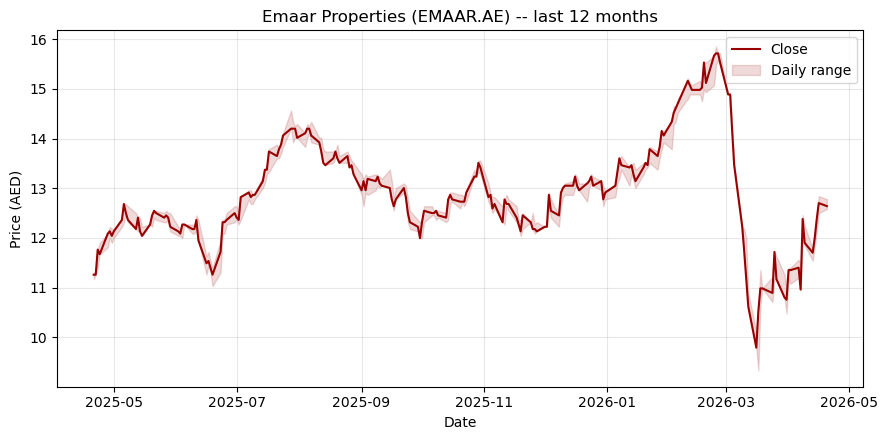

In [8]:
# Plot the closing price with a high-low band
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist.index, hist["Close"], color="#990000", linewidth=1.5, label="Close")
ax.fill_between(hist.index, hist["Low"], hist["High"],
                alpha=0.15, color="#990000", label="Daily range")
ax.set_xlabel("Date"); ax.set_ylabel("Price (AED)")
ax.set_title("Emaar Properties (EMAAR.AE) -- last 12 months")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.2 Company fundamentals

In [9]:
# One call gives you a dictionary of 100+ fundamental fields
info = emaar.info

pick = ["longName", "sector", "industry", "country", "currency",
        "marketCap", "trailingPE", "priceToBook", "dividendYield", "beta"]
for k in pick:
    v = info.get(k, "-")
    if isinstance(v, (int, float)):
        if "Cap" in k:
            print(f"{k:15}: {v / 1e9:,.2f} billion")
        else:
            print(f"{k:15}: {v}")
    else:
        print(f"{k:15}: {v}")


longName       : Emaar Properties PJSC
sector         : Real Estate
industry       : Real Estate - Development
country        : United Arab Emirates
currency       : AED
marketCap      : 111.72 billion
trailingPE     : 6.351759
priceToBook    : 1.1850741
dividendYield  : 7.79
beta           : 0.505


### 6.3 Multiple tickers at once

In [10]:
# yfinance can download many tickers in one batch request
tickers = {
    "EMAAR.AE":       "Emaar Properties",
    "DEWA.AE":        "Dubai Elec & Water",
    "DIB.AE":         "Dubai Islamic Bank",
    "EMIRATESNBD.AE": "Emirates NBD",
    "DU.AE":          "du (telecom)",
    "AIRARABIA.AE":   "Air Arabia",
}

prices = yf.download(list(tickers.keys()),
                     period="1y", auto_adjust=True, progress=False)["Close"]
prices = prices.rename(columns=tickers).dropna(how="all")
prices.tail(3)


Ticker,Air Arabia,Dubai Elec & Water,Dubai Islamic Bank,du (telecom),Emaar Properties,Emirates NBD
Date,,,,,,
2026-04-15,5.08,2.78,7.50,10.4,12.38,30.760000
2026-04-16,5.29,2.75,7.48,10.4,12.70,30.299999
2026-04-20,5.24,2.74,7.31,10.3,12.64,30.200001


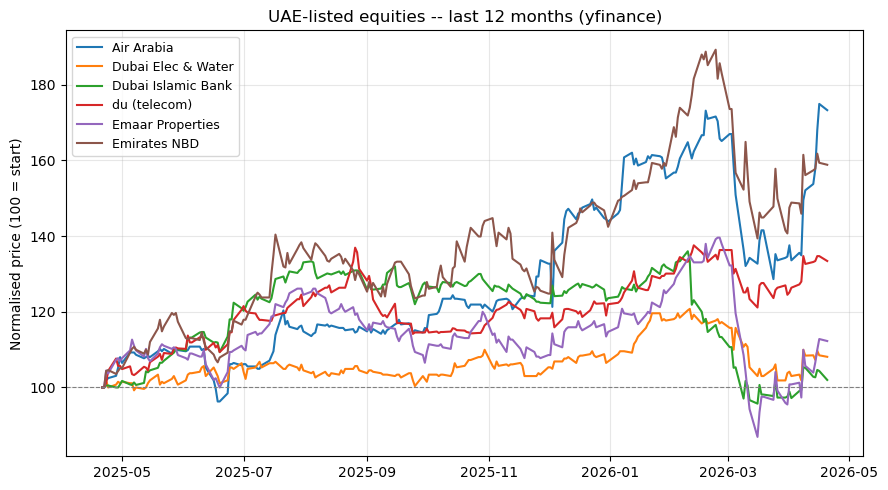

In [11]:
# Normalise to 100 at the starting date -- lets you compare returns cleanly
normed = prices.div(prices.iloc[0]).mul(100)

fig, ax = plt.subplots(figsize=(9, 5))
for col in normed.columns:
    ax.plot(normed.index, normed[col], label=col, linewidth=1.5)
ax.axhline(100, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("Normalised price (100 = start)")
ax.set_title("UAE-listed equities -- last 12 months (yfinance)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.4 Daily returns, correlations, and risk

In [12]:
# Daily log returns from the prices DataFrame
import numpy as np

returns = np.log(prices).diff().dropna()

print("Annualised volatility (%):")
print((returns.std() * np.sqrt(252) * 100).round(2))
print()
print("Correlation matrix:")
print(returns.corr().round(2))


Annualised volatility (%):
Ticker
Air Arabia            37.35
Dubai Elec & Water    22.93
Dubai Islamic Bank    27.95
du (telecom)          23.91
Emaar Properties      37.91
Emirates NBD          42.63
dtype: float64

Correlation matrix:
Ticker              Air Arabia  Dubai Elec & Water  Dubai Islamic Bank  du (telecom)  Emaar Properties  Emirates NBD
Ticker                                                                                                              
Air Arabia                1.00                0.30                0.31          0.26              0.43          0.13
Dubai Elec & Water        0.30                1.00                0.52          0.34              0.49          0.30
Dubai Islamic Bank        0.31                0.52                1.00          0.46              0.56          0.45
du (telecom)              0.26                0.34                0.46          1.00              0.44          0.33
Emaar Properties          0.43                0.49          

In four lines we computed the things a finance analyst actually cares about -- annualised volatility and the correlation matrix of daily returns. This is the payoff of wrapper packages: you spend your code on the *analysis*, not on the *plumbing*.


## 7. `wbdata` -- World Bank Indicators Without Boilerplate

`wbdata` wraps the World Bank API cleanly. It returns pandas DataFrames indexed by date, handles pagination automatically, and has a search function for finding indicators by name.

If the package isn't installed, first install it with `pip install wbdata`. Then you can run the code below to fetch World Bank indicators for the UAE.

### 7.1 Fetch a single indicator for the UAE

In [13]:
import wbdata
import datetime

# GDP in current USD for the UAE, one indicator
gdp = wbdata.get_dataframe(
    {"NY.GDP.MKTP.CD": "gdp_usd"},
    country="ARE",
    date=(datetime.datetime(1990, 1, 1), datetime.datetime(2024, 1, 1)),
)
gdp = gdp.dropna().sort_index()
print(gdp.tail())


           gdp_usd
date              
2020  3.571619e+11
2021  4.224414e+11
2022  5.114034e+11
2023  5.226222e+11
2024  5.523248e+11


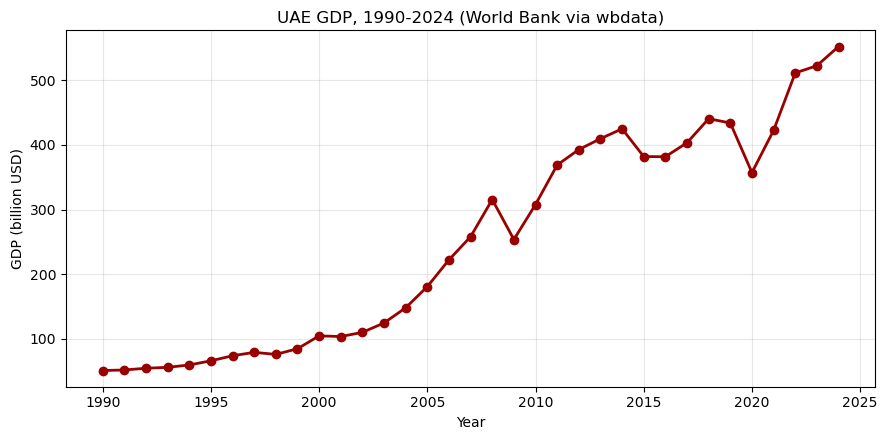

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(gdp.index.astype(int), gdp["gdp_usd"] / 1e9,
        marker="o", color="#990000", linewidth=2)
ax.set_xlabel("Year"); ax.set_ylabel("GDP (billion USD)")
ax.set_title("UAE GDP, 1990-2024 (World Bank via wbdata)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 7.2 Several indicators and several countries in one call

In [15]:
indicators = {
    "NY.GDP.PCAP.CD":  "gdp_per_capita",
    "SP.POP.TOTL":     "population"
}

gcc = wbdata.get_dataframe(
    indicators,
    country=["ARE", "SAU", "QAT", "OMN", "BHR", "KWT"],
    date=(datetime.datetime(1990, 1, 1), datetime.datetime(2022, 1, 1)),
)
# The result has a MultiIndex (country, date) -- pull out the most recent year
latest = gcc.groupby(level=0).apply(lambda g: g.dropna().iloc[-1] if len(g.dropna()) else g.iloc[-1])
latest = latest.droplevel(1) if latest.index.nlevels > 1 else latest
latest.sort_values("gdp_per_capita", ascending=False)


,gdp_per_capita,population
country,,
United Arab Emirates,26709.993440,1898220.0
Qatar,16721.620771,440175.0
Saudi Arabia,11054.749505,10640691.0
Kuwait,10937.541527,1684819.0
Bahrain,9342.538914,514797.0
Oman,7545.703052,1763954.0


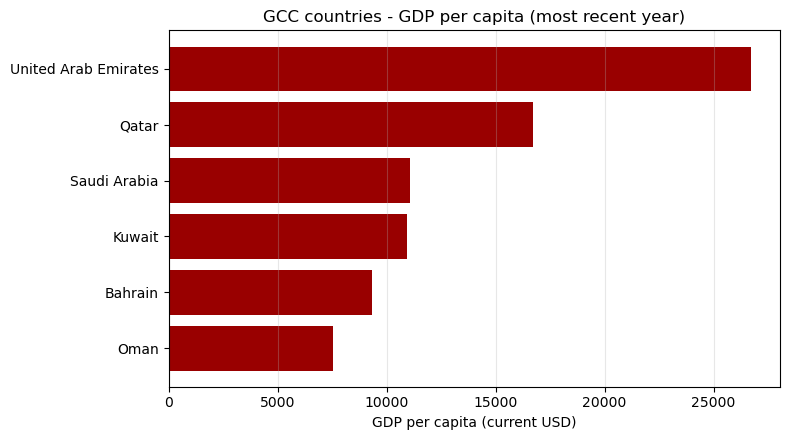

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
data = latest.sort_values("gdp_per_capita", ascending=True)
ax.barh(data.index, data["gdp_per_capita"], color="#990000")
ax.set_xlabel("GDP per capita (current USD)")
ax.set_title("GCC countries - GDP per capita (most recent year)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

In [17]:
# Line chart comparing all GCC country's GDP per capita over time.
# ...
# ...

### Geographical Maps with Data
Many times, it is easier to show dataset values on a map than in a table. In the following code block, we aim to get data from `wbdata`, merge it with `geopandas` country shapes, and plot a choropleth map of GDP per capita in 2021.

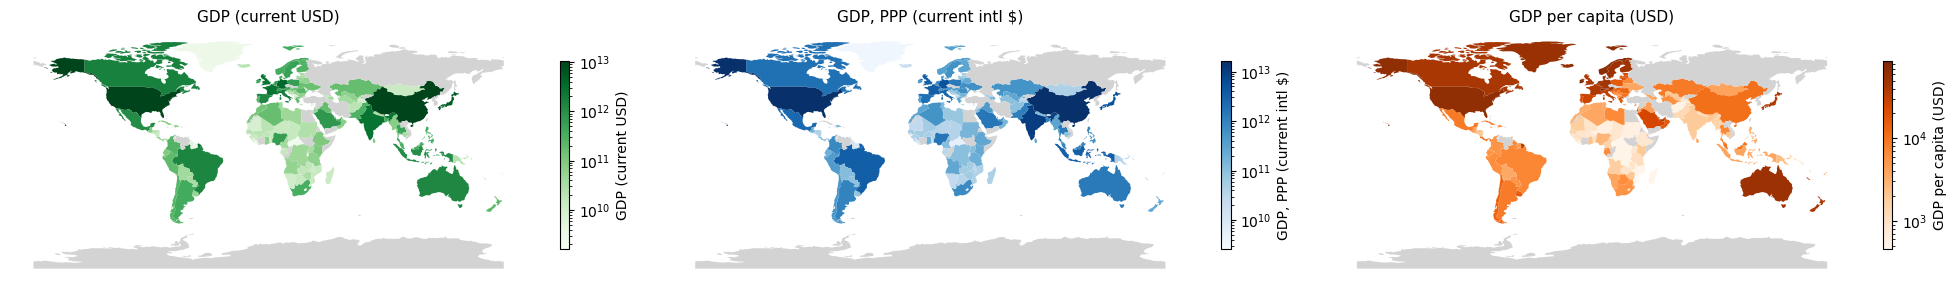

In [19]:
# Making a map plot
import geopandas as gpd
import wbdata
import datetime
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 1. Pull three indicators
world_indicators = {
    "NY.GDP.MKTP.CD":       "gdp",
    "NY.GDP.MKTP.PP.CD":    "gdp_ppp",
    "NY.GDP.PCAP.CD":       "gdp_per_capita",
}

df = wbdata.get_dataframe(
    world_indicators,
    date=(datetime.datetime(2020, 1, 1), datetime.datetime(2022, 1, 1)),
)

# Keep most recent non-null row per country
df_latest = (
    df.groupby(level=0)
    .apply(lambda g: g.dropna().iloc[-1] if len(g.dropna()) else g.iloc[-1])
)
df_latest = df_latest.droplevel(1) if df_latest.index.nlevels > 1 else df_latest
df_latest = df_latest.reset_index().rename(columns={"index": "country"})

# 2. Load world geometries
world = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)

# Manual name fixes for merge mismatches
name_map = {
    "United States of America": "United States",
    "Czechia": "Czech Republic",
    "Republic of the Congo": "Congo, Rep.",
    "Dem. Rep. Congo": "Congo, Dem. Rep.",
    "S. Sudan": "South Sudan",
    "Central African Rep.": "Central African Republic",
    "eSwatini": "Eswatini",
    "Bosnia and Herz.": "Bosnia and Herzegovina",
    "N. Cyprus": "Cyprus",
    "Solomon Is.": "Solomon Islands",
    "Dominican Rep.": "Dominican Republic",
    "Eq. Guinea": "Equatorial Guinea",
}

world["NAME"] = world["NAME"].replace(name_map)
merged = world.merge(df_latest, left_on="NAME", right_on="country", how="left")

# 3. Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

configs = [
    ("gdp",            "GDP (current USD)",         "Greens"),
    ("gdp_ppp",        "GDP, PPP (current intl $)", "Blues"),
    ("gdp_per_capita", "GDP per capita (USD)",       "Oranges"),
]

for ax, (col, title, cmap) in zip(axes, configs):
    merged.plot(
        column=col,
        ax=ax,
        legend=True,
        legend_kwds={"shrink": 0.4, "label": title},
        cmap=cmap,
        missing_kwds={"color": "lightgrey", "label": "No data"},
        norm=mcolors.LogNorm(
            vmin=merged[col].dropna().quantile(0.01),
            vmax=merged[col].dropna().quantile(0.99),
        ),
    )
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

### 7.3 Searching for indicators by name

In [20]:
# Find indicators that mention 'tourism' (use get_indicators with a regex query)
results = wbdata.get_indicators(query="tourism")
for row in results[:8]:
    print(f"{row['id']:30s}  {row['name'][:70]}")


DT.ODA.DACD.PROD.TRSM.CD        Gross ODA aid disbursement for tourism sector, DAC donors total (curre
FC.XPD.TOUR.CR                  Tourism and culture function expenditure (in IDR)
ST.INT.ARVL                     International tourism, number of arrivals
ST.INT.DPRT                     International tourism, number of departures
ST.INT.RCPT.CD                  International tourism, receipts (current US$)
ST.INT.RCPT.XP.ZS               International tourism, receipts (% of total exports)
ST.INT.TRNR.CD                  International tourism, receipts for passenger transport items (current
ST.INT.TRNX.CD                  International tourism, expenditures for passenger transport items (cur


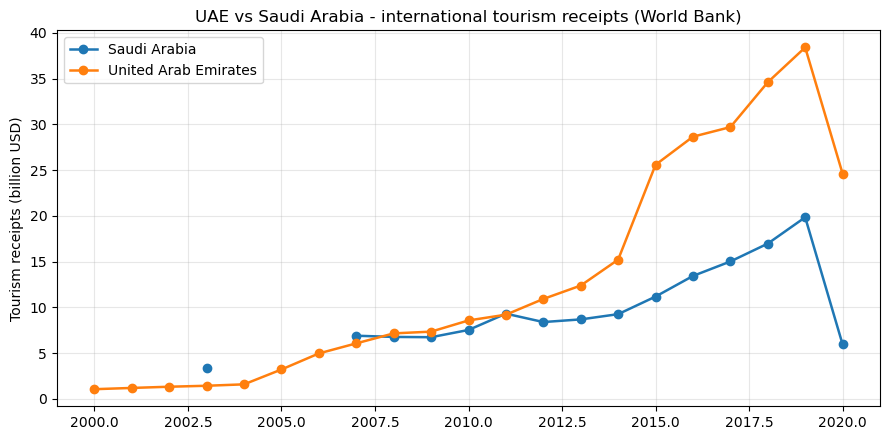

In [21]:
tourism = wbdata.get_dataframe(
    {"ST.INT.RCPT.CD": "receipts_usd"},
    country=["ARE", "SAU"],
    date=(datetime.datetime(2000, 1, 1), datetime.datetime(2022, 1, 1)),
).dropna()

pivot = tourism["receipts_usd"].unstack(level=0)
pivot.index = pivot.index.astype(int)
pivot = pivot.sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col] / 1e9, label=col, marker="o", linewidth=1.8)
ax.set_ylabel("Tourism receipts (billion USD)")
ax.set_title("UAE vs Saudi Arabia - international tourism receipts (World Bank)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Two features to notice:

1. **`get_indicators(query=...)`** lets you discover relevant metrics without opening the World Bank website.
2. **Multi-country, multi-indicator** requests return a single DataFrame with a MultiIndex -- very efficient for comparative analysis.


## 8. `geopy` -- Geocoding Addresses to Coordinates

`geopy` is a unified interface to many geocoding services (Nominatim/OpenStreetMap, Google, Bing, HERE, Mapbox, and more). The Nominatim backend is free and needs no key.

**Business use cases:** mapping customer addresses, placing offices/stores on maps, routing and catchment analyses, enriching databases with coordinates.


### 8.1 Forward and reverse geocoding

In [ ]:
from geopy.geocoders import Nominatim

geo = Nominatim(user_agent="isa383-aus-teaching-notebook", timeout=10)

# Forward: address -> coordinates
aus = geo.geocode("American University of Sharjah, UAE", timeout=10)
print("AUS  :", f"({aus.latitude:.4f}, {aus.longitude:.4f})")
print("Full :", aus.address[:90])
print()

# Reverse: coordinates -> address
rev = geo.reverse((25.2048, 55.2708), language="en")
print("At (25.2048, 55.2708):", rev.address[:90])


### 8.2 Batch-geocoding a list of landmarks

In [ ]:
landmarks = [
    "Burj Khalifa, Dubai",
    "Sheikh Zayed Grand Mosque, Abu Dhabi",
    "Louvre Abu Dhabi",
    "Palm Jumeirah, Dubai",
    "Sharjah Museum of Islamic Civilization",
    "Al Ain Oasis, UAE",
    "American University of Sharjah",
]

rows = []
for place in landmarks:
    loc = geo.geocode(place, timeout=10)
    time.sleep(1)
    if loc:
        rows.append({"name": place.split(",")[0], "lat": loc.latitude, "lon": loc.longitude})
    time.sleep(1)   # Nominatim's usage policy: max 1 request per second

landmark_df = pd.DataFrame(rows)
landmark_df


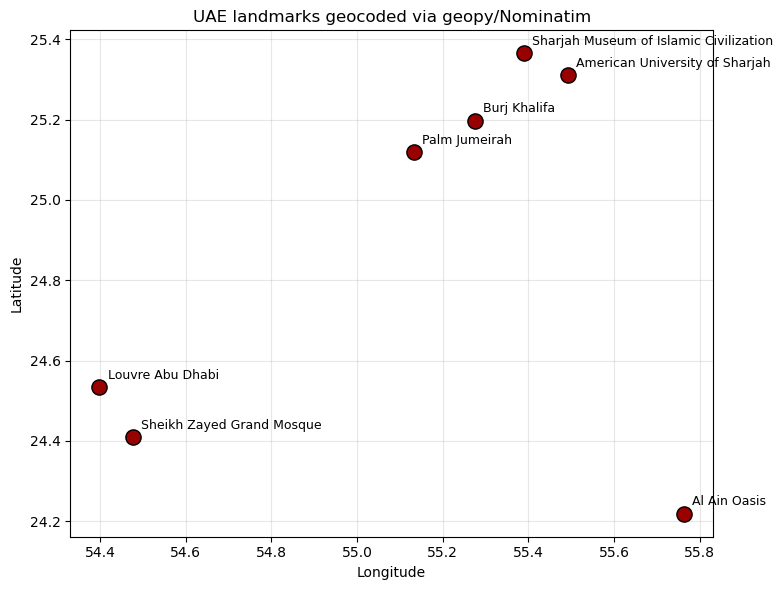

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(landmark_df["lon"], landmark_df["lat"],
           s=120, color="#990000", edgecolor="k", zorder=3)
for _, row in landmark_df.iterrows():
    ax.annotate(row["name"], (row["lon"], row["lat"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("UAE landmarks geocoded via geopy/Nominatim")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 8.3 Distance between coordinates

In [27]:
from geopy.distance import geodesic

dubai    = (25.2048, 55.2708)
sharjah  = (25.3463, 55.4209)
fujairah = (25.1288, 56.3265)
aus_pt   = (25.3109, 55.4919)

for name, coord in [("Sharjah", sharjah), ("Fujairah", fujairah), ("AUS", aus_pt)]:
    km = geodesic(dubai, coord).kilometers
    print(f"Dubai -> {name:10s}: {km:6.1f} km")


Dubai -> Sharjah   :   21.8 km
Dubai -> Fujairah  :  106.8 km
Dubai -> AUS       :   25.2 km


`geodesic` estimates ellipsoidal geodesic distance between two latitude-longitude pairs. It is appropriate for "how far apart are these locations" questions.

**A word about rate limits:** Nominatim's public instance allows **no more than one request per second**, and requires a `user_agent` string. `geopy` will not enforce this for you -- we do with `time.sleep(1)` above. For heavier workloads, switch to a paid geocoder (Google, HERE) or host your own Nominatim server.


## 9. `wikipedia-api` -- Structured Access to Wikipedia

`wikipedia-api` gives you clean, structured access to any Wikipedia article. No HTML parsing, no BeautifulSoup. It is perfect for building reference datasets, lookup tables, or any application that needs a canonical summary of a topic.

You may need to install `wikipedia-api` with `pip install wikipedia-api`.


In [28]:
import wikipediaapi

wiki = wikipediaapi.Wikipedia(user_agent="isa383-class-demo", language="en")

page = wiki.page("United Arab Emirates")
print(f"Exists  : {page.exists()}")
print(f"Title   : {page.title}")
print(f"URL     : {page.fullurl}")
print(f"Summary :\n{page.summary[:400]}...")


Exists  : True
Title   : United Arab Emirates
URL     : https://en.wikipedia.org/wiki/United_Arab_Emirates
Summary :
The United Arab Emirates (UAE), also known simply as the Emirates, is a country in West Asia, situated at the eastern end of the Arabian Peninsula. It is a federal semi-constitutional monarchy made up of seven emirates, with Abu Dhabi serving as its national capital. The UAE borders Oman to the east and northeast, and Saudi Arabia to the southwest. It shares maritime borders with Qatar and Iran in...


### 9.1 Walking the structure of an article

In [39]:
def print_sections(sections, level=0, max_per_level=6):
    for s in sections[:max_per_level]:
        print("  " * level + f"- {s.title}")
        print_sections(s.sections, level + 1, max_per_level)

print_sections(page.sections)


- Etymology
- History
  - Antiquity
  - Islam
  - Portuguese era
  - British era and discovery of oil
  - Independence
  - Post-independence period
- Geography
  - Biodiversity
  - Climate
- Government and politics
  - Administrative divisions
  - Foreign relations
  - Military
  - Law
  - Human rights violations
  - Migrant workers
- Economy
  - Business and finance
  - VAT
  - Energy
  - Tourism
  - Transport
  - Telecommunications
- Demographics
  - Largest cities
  - Language
  - Religion
  - Education
  - Health


### 9.2 Build a DataFrame from many articles

In [29]:
cities = ["Dubai", "Abu Dhabi", "Sharjah", "Ajman",
          "Fujairah", "Ras Al Khaimah", "Umm Al Quwain"]

rows = []
for city in cities:
    p = wiki.page(city)
    if p.exists():
        first_sentence = p.summary.split(". ")[0] + "."
        rows.append({
            "city":        city,
            "first_line":  first_sentence,
            "summary_len": len(p.summary),
            "section_count": len(p.sections),
            "url":         p.fullurl,
        })

cities_df = pd.DataFrame(rows)
cities_df[["city", "section_count", "summary_len"]]


,city,section_count,summary_len
0,Dubai,18,1538
1,Abu Dhabi,19,1659
2,Sharjah,19,1385
3,Ajman,14,377
4,Fujairah,10,412
5,Ras Al Khaimah,13,559
6,Umm Al Quwain,3,1329


In [30]:
# Print the first-line descriptions
for _, row in cities_df.iterrows():
    print(f"* {row['city']}:")
    print(f"  {row['first_line']}\n")


* Dubai:
  Dubai is the most populous city in the United Arab Emirates and the capital of the Emirate of Dubai.

* Abu Dhabi:
  Abu Dhabi is the capital city of the United Arab Emirates (UAE).

* Sharjah:
  Sharjah (; Arabic: ٱلشَّارقَة aš-Šāriqah, Gulf Arabic: aš-Šārja) is a major port city and the third-most populous city in the United Arab Emirates, after Dubai and Abu Dhabi.

* Ajman:
  Ajman (Arabic: عجمان 'Aǧmān; Gulf Arabic: عيمان ʿYmān) is the fifth-largest and fifth-most populous city in the United Arab Emirates, after Dubai, Abu Dhabi, Sharjah, and Al Ain.

* Fujairah:
  Fujairah City (Arabic: الفجيرة) is the capital of the emirate of Fujairah in the United Arab Emirates.

* Ras Al Khaimah:
  Ras Al Khaimah (Arabic: رَأْس ٱلْخَيْمَة; /raʔs͜ ɪlˈxajma/, Emirati Arabic : [räːs͜ ɪlχe̞ːmɛ] ), often referred to its initials RAK, is an industrial port city and the largest city and capital of the Emirate of Ras Al Khaimah in the U.A.E.

* Umm Al Quwain:
  Umm Al Quwain (UAQ; Arabic: 

In twenty lines we built a structured dataset of all seven emirates with summaries, section counts, and URLs -- the kind of thing you might drop into a dashboard or a training set for an NLP project.


`pandas-datareader` is worth knowing for one reason: **FRED is the single best source of free macroeconomic data**, and this is the easiest way to get to it.


## 10. Discovering Packages for Your Own APIs

When you find a new API you want to use, check whether a Python package already exists before writing raw `requests` calls.

**A quick recipe:**

1. Search PyPI: `pip search <service>` was removed, so go to <https://pypi.org> and search in the browser.
2. Search GitHub for `<service> python client`.
3. Check three things before committing to a package:
   - **Maintenance:** last commit date. Anything older than a year is risky.
   - **Stars and forks:** a rough proxy for community trust.
   - **Open issues:** skim the first page to see if there are critical bugs.

**Some popular wrappers worth knowing:**

| Package | Wraps |
|---|---|
| `tweepy`       | X / Twitter API |
| `praw`         | Reddit API |
| `spotipy`      | Spotify Web API |
| `google-api-python-client` | Google (Search, Drive, Sheets, ...) |
| `openai`       | OpenAI / ChatGPT (next lecture!) |
| `anthropic`    | Claude API |
| `boto3`        | Amazon Web Services |
| `python-binance` | Binance cryptocurrency exchange |
| `alpaca-py`    | Alpaca brokerage (stocks, options, crypto) |

Each of these hides the same boilerplate we just saw and exposes a Python-y interface. The mental model is always the same: **a package is a friendly wrapper around `requests.get` and `requests.post`.**


## 11. Mini Project -- Combining Packages

Let us end with a small analysis that chains three of the packages we just learned:

1. Use **`geopy`** to get coordinates for a list of UAE cities.
2. Use **`wikipedia-api`** to get each city's population and one-line summary.
3. Use **`wbdata`** to pull the UAE's GDP per capita for context.

Goal: produce a single tidy DataFrame that could feed a dashboard.


In [ ]:
# Step 1: geocode the cities
target_cities = ["Dubai", "Abu Dhabi", "Sharjah", "Ajman",
                 "Fujairah", "Ras Al Khaimah", "Umm Al Quwain"]

geocoded = []
for city in target_cities:
    loc = geo.geocode(f"{city}, United Arab Emirates", timeout=10)
    time.sleep(1)
    if loc:
        geocoded.append({"city": city, "lat": loc.latitude, "lon": loc.longitude})
    time.sleep(1)   # polite Nominatim pause

geo_df = pd.DataFrame(geocoded)
geo_df


In [32]:
# Step 2: enrich with Wikipedia summaries
summaries = []
for city in target_cities:
    page = wiki.page(city)
    if page.exists():
        summaries.append({
            "city":        city,
            "description": page.summary.split(". ")[0] + ".",
            "wiki_url":    page.fullurl,
        })

wiki_df = pd.DataFrame(summaries)
wiki_df


,city,description,wiki_url
0,Dubai,Dubai is the most populous city in the United ...,https://en.wikipedia.org/wiki/Dubai
1,Abu Dhabi,Abu Dhabi is the capital city of the United Ar...,https://en.wikipedia.org/wiki/Abu_Dhabi
2,Sharjah,"Sharjah (; Arabic: ٱلشَّارقَة aš-Šāriqah, Gulf...",https://en.wikipedia.org/wiki/Sharjah
3,Ajman,Ajman (Arabic: عجمان 'Aǧmān; Gulf Arabic: عيما...,https://en.wikipedia.org/wiki/Ajman
4,Fujairah,Fujairah City (Arabic: الفجيرة) is the capital...,https://en.wikipedia.org/wiki/Fujairah
5,Ras Al Khaimah,Ras Al Khaimah (Arabic: رَأْس ٱلْخَيْمَة; /raʔ...,https://en.wikipedia.org/wiki/Ras_Al_Khaimah
6,Umm Al Quwain,"Umm Al Quwain (UAQ; Arabic: أم القيوين, pronou...",https://en.wikipedia.org/wiki/Umm_Al_Quwain


In [33]:
# Step 3: merge geocoding and Wikipedia
cities_enriched = geo_df.merge(wiki_df, on="city")
cities_enriched


,city,lat,lon,description,wiki_url
0,Dubai,25.074282,55.188539,Dubai is the most populous city in the United ...,https://en.wikipedia.org/wiki/Dubai
1,Abu Dhabi,24.453835,54.377401,Abu Dhabi is the capital city of the United Ar...,https://en.wikipedia.org/wiki/Abu_Dhabi
2,Sharjah,25.360567,56.313500,"Sharjah (; Arabic: ٱلشَّارقَة aš-Šāriqah, Gulf...",https://en.wikipedia.org/wiki/Sharjah
3,Ajman,25.332875,55.996007,Ajman (Arabic: عجمان 'Aǧmān; Gulf Arabic: عيما...,https://en.wikipedia.org/wiki/Ajman
4,Fujairah,25.414736,56.231367,Fujairah City (Arabic: الفجيرة) is the capital...,https://en.wikipedia.org/wiki/Fujairah
5,Ras Al Khaimah,25.773771,55.938232,Ras Al Khaimah (Arabic: رَأْس ٱلْخَيْمَة; /raʔ...,https://en.wikipedia.org/wiki/Ras_Al_Khaimah
6,Umm Al Quwain,25.514494,55.718292,"Umm Al Quwain (UAQ; Arabic: أم القيوين, pronou...",https://en.wikipedia.org/wiki/Umm_Al_Quwain


In [ ]:
# Step 4: pull UAE macro context from the World Bank
uae_macro = wbdata.get_dataframe(
    {"NY.GDP.PCAP.CD": "gdp_per_capita",
     "SP.POP.TOTL":    "population",
     "SL.UEM.TOTL.ZS": "unemployment_pct"},
    country="ARE",
    date=(datetime.datetime(2020, 1, 1), datetime.datetime(2024, 1, 1)),
).dropna().sort_index()

print("UAE macro snapshot, most recent year:")
print(uae_macro.iloc[-1])


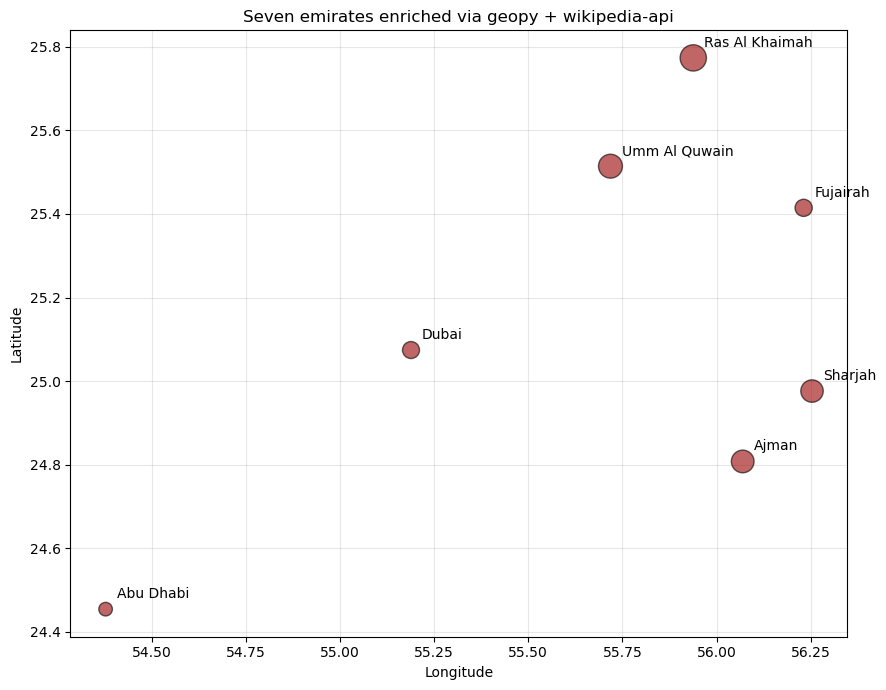

In [48]:
# Step 5: visualise the cities on a map with sizes proportional to (fake) relative prominence
# (Population is not directly available per city from the World Bank; we use the
#  Wikipedia summary length as a rough proxy just to make the scatter sizes meaningful.)
cities_enriched["summary_size"] = cities_enriched["description"].str.len()

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(cities_enriched["lon"], cities_enriched["lat"],
           s=cities_enriched["summary_size"] * 1.5,
           c="#990000", alpha=0.6, edgecolor="k", zorder=3)
for _, row in cities_enriched.iterrows():
    ax.annotate(row["city"], (row["lon"], row["lat"]),
                textcoords="offset points", xytext=(8, 8), fontsize=10)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Seven emirates enriched via geopy + wikipedia-api")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


That is the end-to-end workflow of a package-based analysis:

```
geopy  --->  wikipedia-api  --->  wbdata  --->  pandas
```

Four packages, about sixty lines of code, one tidy dataset you can analyse or plot. This is what modern data work looks like.


## 12. Summary

1. **API clients send HTTP requests.** `requests.get(url, params=...)` is a useful baseline for data-retrieval APIs, while other operations may use POST or another HTTP method. Understanding the request-response pattern helps you debug wrapper packages.
2. **Status codes matter.** Check `response.status_code` (or use `raise_for_status()`) before reading the body.
3. **Keys are secrets.** Never commit them to code. Load from a file or environment variable.
4. **Rate limits are real.** Use `time.sleep`, exponential backoff, or a cached layer.
5. **For popular services, use a package.** `yfinance`, `wbdata`, `geopy`, `wikipedia-api`, and `pandas-datareader` all turn dozens of lines of raw `requests` code into one or two calls.
6. **`requests-cache` is a superpower** -- adding one `install_cache` line makes every subsequent API call in the notebook faster and more reliable.
7. **When picking a package, check maintenance:** last commit, GitHub stars, open issues.

**Next class:** APIs with generative AI -- using the `openai` and `anthropic` packages to build intelligent tools on top of large language models.


## 13. Exercises

1. **yfinance.** Pick a UAE-listed or Saudi-listed stock of your choice. Download its last 2 years of daily prices and compute (a) its annualised return, (b) its annualised volatility, and (c) its maximum drawdown.

2. **wbdata.** Use `wbdata.get_indicators(query=...)` to find an indicator related to *education* (hint: try the keyword "literacy" or "school"). Download that indicator for the UAE and plot it over time.

3. **geopy.** Pick five places in your home country that you care about (your school, your favourite restaurant, a park, ...) and geocode them. Compute the pairwise distances in kilometres between all five using `geodesic`. Which two are the furthest apart?

4. **wikipedia-api.** Build a DataFrame with the five most populous cities in your country: their first-sentence summary, their Wikipedia URL, and the number of sections in their article.

5. **pandas-datareader.** Download the US Consumer Price Index (`CPIAUCSL`) from FRED between 2000 and today. Compute the year-over-year inflation rate and plot it.

6. **requests-cache.** Run the same `wbdata.get_dataframe(...)` call twice, once with and once without `requests_cache.install_cache(...)`. Time both calls and compare. How much faster is the cached version?

7. **Your pick.** Find *any* free API that interests you (sports, games, weather, flights, ...). Search PyPI for a wrapper package for it. If you find one, use it to pull data and plot something. If you don't, fall back to raw `requests`.

---

*Submit your completed notebook by the deadline in the course schedule for Participation credit.*
